In [1]:
import os

os.environ['KAGGLE_USERNAME'] = 'orchidali'
os.environ['KAGGLE_KEY'] = 'ae5bd67002627f761344663d412d5c51'


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

print("Path to dataset files:", path)

100%|██████████| 429M/429M [03:42<00:00, 2.03MB/s] 

Extracting files...


Path to dataset files: /Users/robamahmoud/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1


In [3]:
# dataset_path = "C:\\Users\\Orchid Hazem\\.cache\\kagglehub\\datasets\\uwrfkaggler\\ravdess-emotional-speech-audio\\versions\\1"

In [9]:
import os
import pandas as pd

# Path to the dataset
dataset_path = "/Users/robamahmoud/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1"
# Initialize a list to store metadata
data = []

# Emotion mapping to the three main categories
main_emotion_mapping = {
    "01": "neutral",   # neutral
    "02": "happy",     # calm (grouped under happy)
    "03": "happy",     # happy
    "04": "sad",       # sad
    "05": "sad",       # angry (grouped under sad)
    "06": "sad",       # fearful (grouped under sad)
    "07": "sad",       # disgust (grouped under sad)
    "08": "happy"      # surprised (grouped under happy)
}

# Walk through the dataset directory
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            # Extract metadata from the file name
            parts = file.split("-")
            if len(parts) >= 3:  # Ensure the file name has enough parts
                emotion = parts[2]  # Extract the emotion code

                # Map the emotion code to the main emotion category
                main_emotion = main_emotion_mapping.get(emotion, "unknown")

                # Append metadata and file path to the list
                data.append({
                    "file_path": os.path.join(root, file),  # Full file path
                    "emotion": main_emotion                 # Emotion label
                })

# Convert the list to a DataFrame
df = pd.DataFrame(data)

# Save the dataset as a JSON file
df.to_json("ravdess_main_emotions.json", orient="records", indent=4)
print("Dataset saved to ravdess_main_emotions.json")


Dataset saved to ravdess_main_emotions.json


In [10]:
df

,file_path,emotion
0,/Users/robamahmoud/.cache/kagglehub/datasets/u...,sad
1,/Users/robamahmoud/.cache/kagglehub/datasets/u...,sad
2,/Users/robamahmoud/.cache/kagglehub/datasets/u...,sad
3,/Users/robamahmoud/.cache/kagglehub/datasets/u...,sad
4,/Users/robamahmoud/.cache/kagglehub/datasets/u...,sad
...,...,...
2875,/Users/robamahmoud/.cache/kagglehub/datasets/u...,happy
2876,/Users/robamahmoud/.cache/kagglehub/datasets/u...,happy
2877,/Users/robamahmoud/.cache/kagglehub/datasets/u...,happy
2878,/Users/robamahmoud/.cache/kagglehub/datasets/u...,happy


In [11]:
import librosa
import numpy as np
import pandas as pd
import json
import os

# Load the JSON file containing audio paths and emotions
with open("ravdess_main_emotions.json", "r") as f:
    audio_data = json.load(f)

# Select a subset of 1,000 samples
audio_data_subset = audio_data[:1000]  # First 1,000 items

# Initialize a list to store extracted features
features = []

for item in audio_data_subset:
    file_path = item["file_path"]
    emotion = item["emotion"]

    try:
        # Load the audio file
        y, sr = librosa.load(file_path, sr=None)

        # Extract features
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).mean(axis=1)  # 13 MFCCs
        pitch = librosa.piptrack(y=y, sr=sr)[0].mean()                    # Mean pitch
        intensity = np.mean(librosa.feature.rms(y=y))                     # Root Mean Square (RMS)

        # Store features and label
        features.append({
            "file_path": file_path,
            "emotion": emotion,
            **{f"mfcc_{i+1}": mfccs[i] for i in range(len(mfccs))},
            "pitch": pitch,
            "intensity": intensity,
        })
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Convert to DataFrame
df = pd.DataFrame(features)

# Save the DataFrame to a CSV file
df.to_csv("audio_features_sample.csv", index=False)
print("Feature extraction complete and saved to audio_features_sample.csv")


Feature extraction complete and saved to audio_features_sample.csv


In [12]:
import matplotlib.pyplot as plt
import librosa.display

output_dir = "spectrograms_sample"
os.makedirs(output_dir, exist_ok=True)

for item in audio_data_subset:
    file_path = item["file_path"]
    emotion = item["emotion"]

    try:
        # Load audio
        y, sr = librosa.load(file_path, sr=None)

        # Generate a Mel spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
        S_dB = librosa.power_to_db(S, ref=np.max)

        # Plot and save the spectrogram
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', fmax=8000)
        plt.colorbar(format='%+2.0f dB')
        plt.title(f'Mel Spectrogram - {emotion}')
        plt.tight_layout()

        # Save as image
        output_path = os.path.join(output_dir, f"{os.path.basename(file_path)}.png")
        plt.savefig(output_path)
        plt.close()
    except Exception as e:
        print(f"Error creating spectrogram for {file_path}: {e}")

print("Spectrogram images for 1,000 samples saved to the spectrograms_sample directory.")


Spectrogram images for 1,000 samples saved to the spectrograms_sample directory.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd
from torchvision.transforms import transforms
import torchvision.models as models
import os
from PIL import Image

# Data Splitting (80% Train, 10% Validation, 10% Test)
csv_file = "audio_features_sample.csv"
spectrogram_dir = "spectrograms_sample"
df = pd.read_csv(csv_file)

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['emotion'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['emotion'])

print(f"Training samples: {len(train_df)}, Validation samples: {len(val_df)}, Test samples: {len(test_df)}")

# Dataset Class
class AudioEmotionDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, spectrogram_dir, transform=None):
        self.data = dataframe
        self.spectrogram_dir = spectrogram_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        file_path = row['file_path']
        emotion = row['emotion']

        # Load spectrogram as image
        spectrogram_path = os.path.join(self.spectrogram_dir, os.path.basename(file_path) + ".png")
        image = Image.open(spectrogram_path).convert('L')  # Convert to grayscale
        if self.transform:
            image = self.transform(image)

        # Map emotion to label
        emotion_map = {"neutral": 0, "happy": 1, "sad": 2}
        label = emotion_map[emotion]
        return image, label

# Transforms
transform_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3 channels
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

transform_val_test = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3 channels
    transforms.ToTensor()
])


# DataLoaders
batch_size = 32
train_dataset = AudioEmotionDataset(train_df, spectrogram_dir, transform=transform_train)
val_dataset = AudioEmotionDataset(val_df, spectrogram_dir, transform=transform_val_test)
test_dataset = AudioEmotionDataset(test_df, spectrogram_dir, transform=transform_val_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Improved Model with ResNet
class AudioEmotionModel(nn.Module):
    def __init__(self, num_classes):
        super(AudioEmotionModel, self).__init__()
        # Use ResNet18 as a feature extractor
        self.resnet = models.resnet18(pretrained=True)
        self.resnet.fc = nn.Identity()  # Remove the final classification layer
        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.resnet(x)  # Extract features
        output = self.fc(features)  # Classify
        return output

# Handle Class Imbalance with Weighted Loss
emotion_counts = train_df['emotion'].value_counts()
class_weights = [1.0 / emotion_counts[emotion] for emotion in ["neutral", "happy", "sad"]]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)  # Ensure weights are float
criterion = nn.CrossEntropyLoss(weight=class_weights)


# Training and Validation Loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AudioEmotionModel(num_classes=3).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=0.0001)
num_epochs = 30  # Higher epochs to allow better convergence

# Helper function for accuracy
def calculate_accuracy(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Training with Early Stopping
best_val_accuracy = 0.0
patience = 5  # Stop training after 5 epochs without improvement
patience_counter = 0

# Training Loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    val_running_loss = 0.0

    # Training Phase
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).long()  # Ensure labels are torch.long

        # Forward pass
        outputs = model(images)  # No need to cast to float; it's already float
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation Phase
    model.eval()
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).long()  # Ensure labels are torch.long
            outputs = model(images)  # No need to cast to float; it's already float
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    val_loss = val_running_loss / len(val_loader)
    val_accuracy = calculate_accuracy(model, val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")



Training samples: 800, Validation samples: 100, Test samples: 100


/opt/anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/30], Train Loss: 1.1156, Validation Loss: 1.0757, Validation Accuracy: 48.00%
Epoch [2/30], Train Loss: 0.9909, Validation Loss: 0.8455, Validation Accuracy: 51.00%
Epoch [3/30], Train Loss: 0.8193, Validation Loss: 0.6674, Validation Accuracy: 72.00%
Epoch [4/30], Train Loss: 0.7154, Validation Loss: 0.6236, Validation Accuracy: 62.00%
Epoch [5/30], Train Loss: 0.6501, Validation Loss: 0.5676, Validation Accuracy: 65.00%
Epoch [6/30], Train Loss: 0.5957, Validation Loss: 0.4487, Validation Accuracy: 80.00%
Epoch [7/30], Train Loss: 0.5488, Validation Loss: 0.4860, Validation Accuracy: 72.00%
Epoch [8/30], Train Loss: 0.4678, Validation Loss: 0.3505, Validation Accuracy: 83.00%
Epoch [9/30], Train Loss: 0.4018, Validation Loss: 0.4764, Validation Accuracy: 92.00%
Epoch [10/30], Train Loss: 0.3541, Validation Loss: 0.2855, Validation Accuracy: 83.00%
Epoch [11/30], Train Loss: 0.3094, Validation Loss: 0.2319, Validation Accuracy: 93.00%
Epoch [12/30], Train Loss: 0.2392, Valida

In [ ]:
test_accuracy = calculate_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 97.00%


In [ ]:
torch.save(model.state_dict(), "best_audio_emotion_model.pth")  # Save the best model


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Best Model
model.load_state_dict(torch.load("best_audio_emotion_model.pth"))
model.eval()

# Helper Function to Compute Metrics
def evaluate_model(model, dataloader):
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device).long()
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_preds, all_labels

# Evaluate on Test Dataset
preds, labels = evaluate_model(model, test_loader)

# Accuracy
test_accuracy = (np.array(preds) == np.array(labels)).mean() * 100
print(f"Test Accuracy: {test_accuracy:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=["Neutral", "Happy", "Sad"]))




C:\Users\Orchid Hazem\AppData\Local\Temp\ipykernel_18180\2717710093.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_audio_emotion_

Test Accuracy: 97.00%

Classification Report:
              precision    recall  f1-score   support

     Neutral       1.00      0.57      0.73         7
       Happy       0.93      1.00      0.96        40
         Sad       1.00      1.00      1.00        53

    accuracy                           0.97       100
   macro avg       0.98      0.86      0.90       100
weighted avg       0.97      0.97      0.97       100



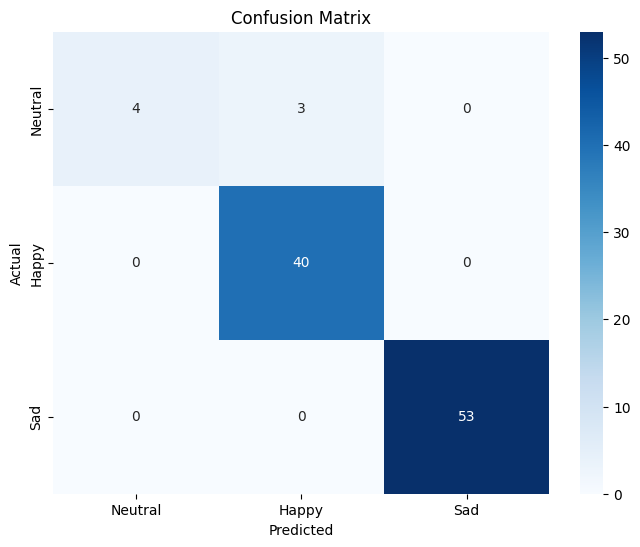

In [ ]:
# Confusion Matrix
conf_matrix = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Neutral", "Happy", "Sad"], yticklabels=["Neutral", "Happy", "Sad"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()